<a href="https://colab.research.google.com/github/saransh-debugs/CMPE_258_Excellent/blob/main/hw1_excellent_gemm_benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 1 — Excellent: CUDA Core vs Tensor Core GEMM Benchmark

**Goal:** Measure and explain the performance difference between a "traditional CUDA-core" GEMM path and a "modern Tensor Core" GEMM path using a simple fully connected layer.

---

## Part 0: GPU Verification

In [14]:
!nvidia-smi
import torch
cc = torch.cuda.get_device_capability(0)

Sat Mar 28 04:51:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             60W /  400W |    1552MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Part 1: PyTorch FC Layer Benchmark

We implement a simple fully connected (linear) layer and benchmark:
- **Mode 1 (CUDA Core baseline):** FP32 matmul with TF32 disabled
- **Mode 2 (Tensor Core):** FP32 matmul with TF32 enabled

In [15]:
import torch
import torch.nn as nn
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 12})

def benchmark_pytorch_fc(M, K, N, mode='tf32_off', warmup=20, iters=100):
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

    # Create FC layer and input
    fc = nn.Linear(K, N, bias=True).cuda().float()
    x = torch.randn(M, K, device='cuda', dtype=torch.float32)

    # Warm-up
    for _ in range(warmup):
        _ = fc(x)
    torch.cuda.synchronize()

    # Timed iterations using CUDA events
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    times = []
    for _ in range(iters):
        start_event.record()
        _ = fc(x)
        end_event.record()
        torch.cuda.synchronize()
        times.append(start_event.elapsed_time(end_event))  # ms

    avg_ms = np.mean(times)
    std_ms = np.std(times)

    # Throughput: FLOPS for matmul = 2*M*N*K (multiply-add), + 2*M*N for bias
    flops = 2.0 * M * N * K + 2.0 * M * N
    tflops = (flops / (avg_ms / 1000.0)) / 1e12

    return avg_ms, std_ms, tflops

In [16]:
# Sweep sizes: square matrices for simplicity (M=K=N)
sizes = [256, 512, 1024, 2048, 4096, 8192]

results_pytorch = {'sizes': sizes, 'tf32_off': [], 'tf32_on': []}

print(f"{'Size':>6} | {'FP32 (no TF32)':>16} | {'FP32 (TF32 on)':>16} | {'Speedup':>8}")
print("-" * 60)

for size in sizes:
    M, K, N = size, size, size

    avg_off, std_off, tflops_off = benchmark_pytorch_fc(M, K, N, mode='tf32_off')
    avg_on, std_on, tflops_on = benchmark_pytorch_fc(M, K, N, mode='tf32_on')

    results_pytorch['tf32_off'].append({'avg_ms': avg_off, 'std_ms': std_off, 'tflops': tflops_off})
    results_pytorch['tf32_on'].append({'avg_ms': avg_on, 'std_ms': std_on, 'tflops': tflops_on})

    speedup = avg_off / avg_on
    print(f"{size:>6} | {avg_off:>10.3f} ms    | {avg_on:>10.3f} ms    | {speedup:>7.2f}x")

print("\nPyTorch benchmark complete!")

  Size |   FP32 (no TF32) |   FP32 (TF32 on) |  Speedup
------------------------------------------------------------
   256 |      0.067 ms    |      0.067 ms    |    1.01x
   512 |      0.061 ms    |      0.061 ms    |    1.00x
  1024 |      0.076 ms    |      0.076 ms    |    1.00x
  2048 |      0.216 ms    |      0.224 ms    |    0.96x
  4096 |      1.141 ms    |      1.141 ms    |    1.00x
  8192 |      8.571 ms    |      8.577 ms    |    1.00x

PyTorch benchmark complete!


### Numerical Accuracy Check
TF32 reduces mantissa from 23 bits to 10 bits. Let's verify the accuracy trade-off.

In [17]:
# Accuracy comparison
M, K, N = 2048, 2048, 2048
fc = nn.Linear(K, N, bias=True).cuda().float()
x = torch.randn(M, K, device='cuda', dtype=torch.float32)

# FP32 result (no TF32)
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
out_fp32 = fc(x)

# TF32 result
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
out_tf32 = fc(x)

# Compute difference
abs_diff = (out_fp32 - out_tf32).abs()
rel_diff = abs_diff / (out_fp32.abs() + 1e-8)

print(f"Max absolute difference:  {abs_diff.max().item():.6e}")
print(f"Mean absolute difference: {abs_diff.mean().item():.6e}")
print(f"Max relative difference:  {rel_diff.max().item():.6e}")
print(f"Mean relative difference: {rel_diff.mean().item():.6e}")
print(f"\nFP32 output range: [{out_fp32.min().item():.2f}, {out_fp32.max().item():.2f}]")

Max absolute difference:  9.066015e-04
Mean absolute difference: 1.383307e-04
Max relative difference:  1.510017e+03
Mean relative difference: 3.268736e-03

FP32 output range: [-3.01, 3.43]


## Part 2: CUDA C++ / cuBLAS Benchmark

Now we implement the same comparison using cuBLAS directly:
- **Baseline:** `cublasSgemm` (FP32 CUDA cores)
- **Tensor Core:** `cublasGemmEx` with TF32 compute

In [18]:
%%writefile gemm_benchmark.cu
#include <cublas_v2.h>
#include <cuda_runtime.h>
#include <cstdio>
#include <cstdlib>
#include <cmath>
#include <vector>

#define CHECK_CUDA(call) do { \
    cudaError_t err = call; \
    if (err != cudaSuccess) { \
        fprintf(stderr, "CUDA error at %s:%d: %s\n", __FILE__, __LINE__, cudaGetErrorString(err)); \
        exit(1); \
    } \
} while(0)

#define CHECK_CUBLAS(call) do { \
    cublasStatus_t stat = call; \
    if (stat != CUBLAS_STATUS_SUCCESS) { \
        fprintf(stderr, "cuBLAS error at %s:%d: %d\n", __FILE__, __LINE__, stat); \
        exit(1); \
    } \
} while(0)


void fill_random(float* arr, int n) {
    for (int i = 0; i < n; i++)
        arr[i] = ((float)rand() / RAND_MAX) * 2.0f - 1.0f;
}


float benchmark_sgemm(cublasHandle_t handle, int M, int N, int K,
                      float* d_A, float* d_B, float* d_C,
                      int warmup, int iters) {
    float alpha = 1.0f, beta = 0.0f;
    CHECK_CUBLAS(cublasSetMathMode(handle, CUBLAS_DEFAULT_MATH));
    for (int i = 0; i < warmup; i++) {
        CHECK_CUBLAS(cublasSgemm(handle, CUBLAS_OP_N, CUBLAS_OP_N,
                                 N, M, K, &alpha, d_B, N, d_A, K, &beta, d_C, N));
    }
    CHECK_CUDA(cudaDeviceSynchronize());

    cudaEvent_t start, stop;
    CHECK_CUDA(cudaEventCreate(&start));
    CHECK_CUDA(cudaEventCreate(&stop));

    float total_ms = 0.0f;
    for (int i = 0; i < iters; i++) {
        CHECK_CUDA(cudaEventRecord(start));
        CHECK_CUBLAS(cublasSgemm(handle, CUBLAS_OP_N, CUBLAS_OP_N,
                                 N, M, K, &alpha, d_B, N, d_A, K, &beta, d_C, N));
        CHECK_CUDA(cudaEventRecord(stop));
        CHECK_CUDA(cudaEventSynchronize(stop));
        float ms = 0.0f;
        CHECK_CUDA(cudaEventElapsedTime(&ms, start, stop));
        total_ms += ms;
    }

    CHECK_CUDA(cudaEventDestroy(start));
    CHECK_CUDA(cudaEventDestroy(stop));

    return total_ms / iters;
}

float benchmark_tf32(cublasHandle_t handle, int M, int N, int K,
                     float* d_A, float* d_B, float* d_C,
                     int warmup, int iters) {
    float alpha = 1.0f, beta = 0.0f;

    CHECK_CUBLAS(cublasSetMathMode(handle, CUBLAS_TF32_TENSOR_OP_MATH));
    for (int i = 0; i < warmup; i++) {
        CHECK_CUBLAS(cublasGemmEx(handle, CUBLAS_OP_N, CUBLAS_OP_N,
                                  N, M, K,
                                  &alpha,
                                  d_B, CUDA_R_32F, N,
                                  d_A, CUDA_R_32F, K,
                                  &beta,
                                  d_C, CUDA_R_32F, N,
                                  CUBLAS_COMPUTE_32F_FAST_TF32,
                                  CUBLAS_GEMM_DEFAULT_TENSOR_OP));
    }
    CHECK_CUDA(cudaDeviceSynchronize());

    cudaEvent_t start, stop;
    CHECK_CUDA(cudaEventCreate(&start));
    CHECK_CUDA(cudaEventCreate(&stop));

    float total_ms = 0.0f;
    for (int i = 0; i < iters; i++) {
        CHECK_CUDA(cudaEventRecord(start));
        CHECK_CUBLAS(cublasGemmEx(handle, CUBLAS_OP_N, CUBLAS_OP_N,
                                  N, M, K,
                                  &alpha,
                                  d_B, CUDA_R_32F, N,
                                  d_A, CUDA_R_32F, K,
                                  &beta,
                                  d_C, CUDA_R_32F, N,
                                  CUBLAS_COMPUTE_32F_FAST_TF32,
                                  CUBLAS_GEMM_DEFAULT_TENSOR_OP));
        CHECK_CUDA(cudaEventRecord(stop));
        CHECK_CUDA(cudaEventSynchronize(stop));
        float ms = 0.0f;
        CHECK_CUDA(cudaEventElapsedTime(&ms, start, stop));
        total_ms += ms;
    }

    CHECK_CUDA(cudaEventDestroy(start));
    CHECK_CUDA(cudaEventDestroy(stop));

    return total_ms / iters;
}

int main() {
    cudaDeviceProp prop;
    CHECK_CUDA(cudaGetDeviceProperties(&prop, 0));
    cublasHandle_t handle;
    CHECK_CUBLAS(cublasCreate(&handle));

    int sizes[] = {256, 512, 1024, 2048, 4096, 8192};
    int n_sizes = sizeof(sizes) / sizeof(sizes[0]);
    int warmup = 20;
    int iters = 100;

    // CSV header for easy parsing
    printf("CSV_START\n");
    printf("size,sgemm_ms,tf32_ms,speedup,sgemm_tflops,tf32_tflops\n");

    for (int s = 0; s < n_sizes; s++) {
        int M = sizes[s], N = sizes[s], K = sizes[s];
        size_t size_A = (size_t)M * K * sizeof(float);
        size_t size_B = (size_t)K * N * sizeof(float);
        size_t size_C = (size_t)M * N * sizeof(float);

        float *h_A = (float*)malloc(size_A);
        float *h_B = (float*)malloc(size_B);
        fill_random(h_A, M * K);
        fill_random(h_B, K * N);

        float *d_A, *d_B, *d_C;
        CHECK_CUDA(cudaMalloc(&d_A, size_A));
        CHECK_CUDA(cudaMalloc(&d_B, size_B));
        CHECK_CUDA(cudaMalloc(&d_C, size_C));

        CHECK_CUDA(cudaMemcpy(d_A, h_A, size_A, cudaMemcpyHostToDevice));
        CHECK_CUDA(cudaMemcpy(d_B, h_B, size_B, cudaMemcpyHostToDevice));

        float sgemm_ms = benchmark_sgemm(handle, M, N, K, d_A, d_B, d_C, warmup, iters);
        float tf32_ms  = benchmark_tf32(handle, M, N, K, d_A, d_B, d_C, warmup, iters);

        // Compute throughput (TFLOPS)
        double flops = 2.0 * M * N * K;
        double sgemm_tflops = (flops / (sgemm_ms / 1000.0)) / 1e12;
        double tf32_tflops  = (flops / (tf32_ms / 1000.0)) / 1e12;
        float speedup = sgemm_ms / tf32_ms;

        printf("%d,%.4f,%.4f,%.2f,%.2f,%.2f\n",
               sizes[s], sgemm_ms, tf32_ms, speedup, sgemm_tflops, tf32_tflops);

        // Cleanup
        CHECK_CUDA(cudaFree(d_A));
        CHECK_CUDA(cudaFree(d_B));
        CHECK_CUDA(cudaFree(d_C));
        free(h_A);
        free(h_B);
    }
    printf("CSV_END\n");

    CHECK_CUBLAS(cublasDestroy(handle));
    return 0;
}

Overwriting gemm_benchmark.cu


In [19]:
# Compile the CUDA benchmark
!nvcc gemm_benchmark.cu -o gemm_benchmark -lcublas -O3
print("Compilation successful!")

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Compilation successful!


In [20]:
# Run the cuBLAS benchmark
import subprocess
result = subprocess.run(['./gemm_benchmark'], capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

# Parse cuBLAS CSV output
import csv
from io import StringIO

output = result.stdout
csv_data = output.split('CSV_START\n')[1].split('CSV_END')[0]
reader = csv.DictReader(StringIO(csv_data))

results_cublas = {'sizes': [], 'sgemm': [], 'tf32': []}
for row in reader:
    results_cublas['sizes'].append(int(row['size']))
    results_cublas['sgemm'].append({'avg_ms': float(row['sgemm_ms']), 'tflops': float(row['sgemm_tflops'])})
    results_cublas['tf32'].append({'avg_ms': float(row['tf32_ms']), 'tflops': float(row['tf32_tflops'])})

print("\ncuBLAS Results Parsed:")
print(f"{'Size':>6} | {'Sgemm (ms)':>12} | {'TF32 (ms)':>12} | {'Speedup':>8} | {'Sgemm TFLOPS':>14} | {'TF32 TFLOPS':>12}")
print("-" * 80)
for i, size in enumerate(results_cublas['sizes']):
    sg = results_cublas['sgemm'][i]
    tf = results_cublas['tf32'][i]
    speedup = sg['avg_ms'] / tf['avg_ms']
    print(f"{size:>6} | {sg['avg_ms']:>10.4f}   | {tf['avg_ms']:>10.4f}   | {speedup:>7.2f}x | {sg['tflops']:>12.2f}   | {tf['tflops']:>10.2f}")

CSV_START
size,sgemm_ms,tf32_ms,speedup,sgemm_tflops,tf32_tflops
256,0.0231,0.0207,1.11,1.45,1.62
512,0.0414,0.0212,1.95,6.49,12.66
1024,0.1649,0.0470,3.51,13.02,45.68
2048,1.1399,0.1919,5.94,15.07,89.52
4096,7.2896,1.1240,6.49,18.85,122.28
8192,57.3359,8.6481,6.63,19.18,127.14
CSV_END


cuBLAS Results Parsed:
  Size |   Sgemm (ms) |    TF32 (ms) |  Speedup |   Sgemm TFLOPS |  TF32 TFLOPS
--------------------------------------------------------------------------------
   256 |     0.0231   |     0.0207   |    1.12x |         1.45   |       1.62
   512 |     0.0414   |     0.0212   |    1.95x |         6.49   |      12.66
  1024 |     0.1649   |     0.0470   |    3.51x |        13.02   |      45.68
  2048 |     1.1399   |     0.1919   |    5.94x |        15.07   |      89.52
  4096 |     7.2896   |     1.1240   |    6.49x |        18.85   |     122.28
  8192 |    57.3359   |     8.6481   |    6.63x |        19.18   |     127.14


## Part 3: Comparison Plots

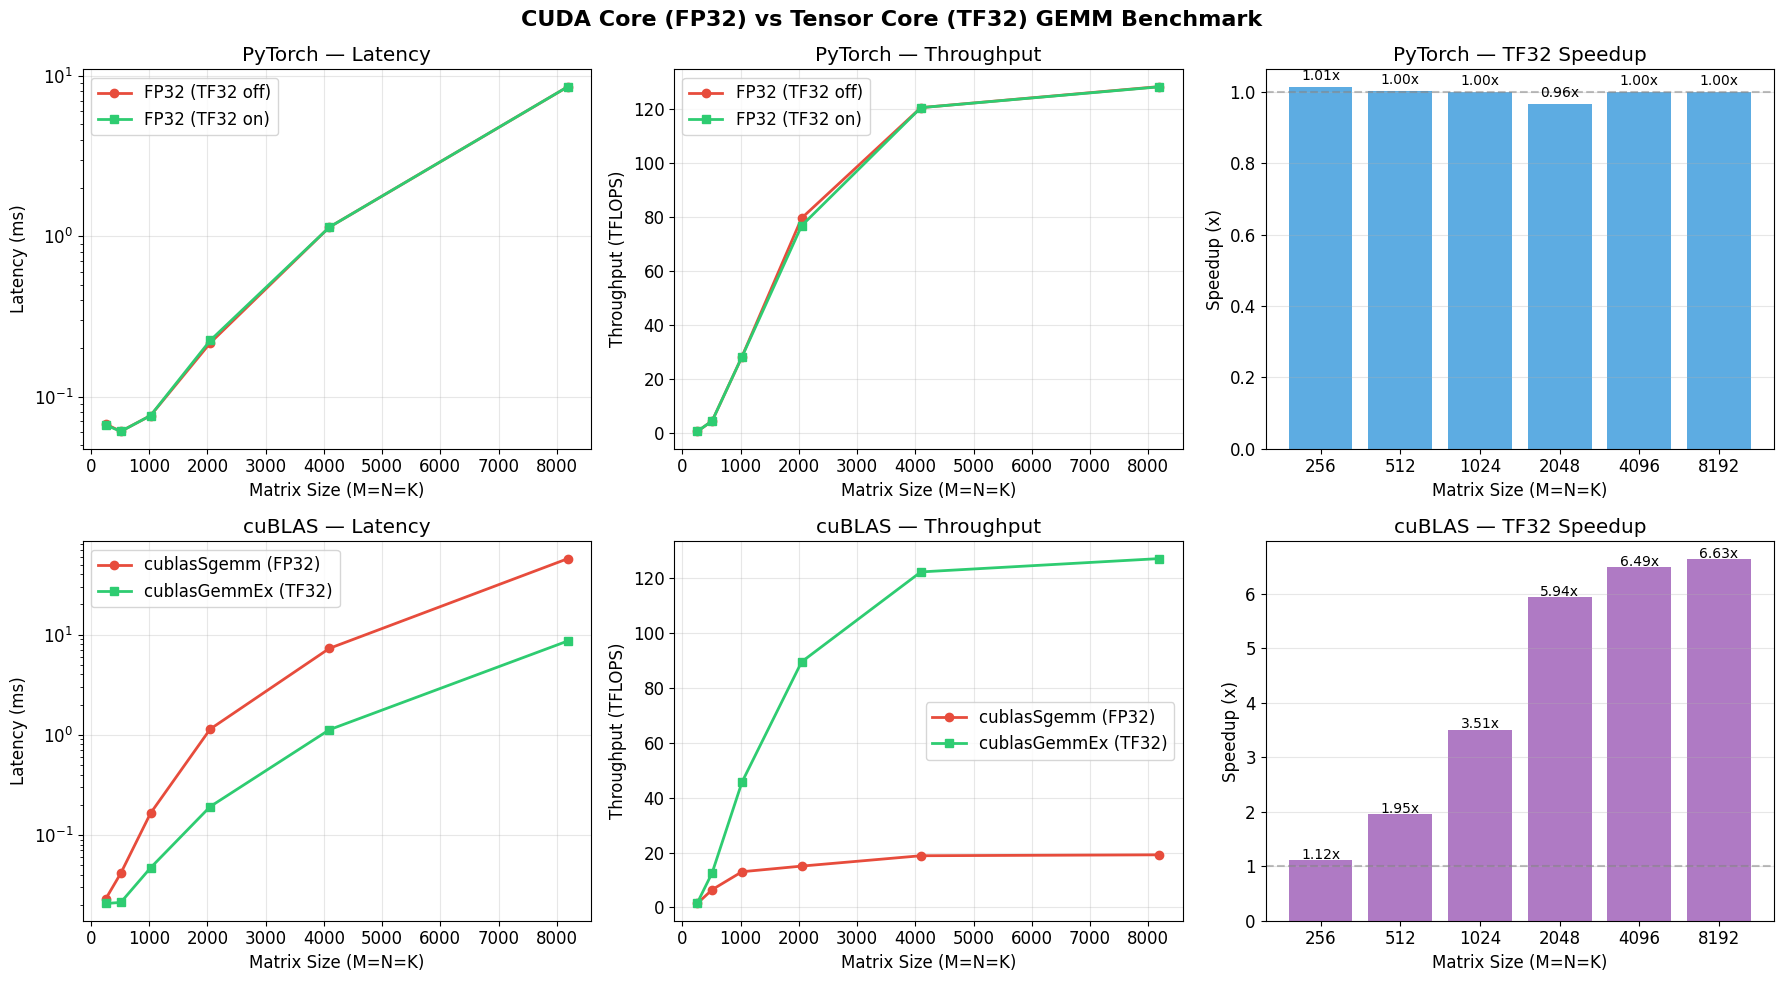

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('CUDA Core (FP32) vs Tensor Core (TF32) GEMM Benchmark', fontsize=16, fontweight='bold')

sizes_pt = results_pytorch['sizes']
sizes_cb = results_cublas['sizes']

# --- Row 1: PyTorch ---
# Latency
ax = axes[0, 0]
pt_off_ms = [r['avg_ms'] for r in results_pytorch['tf32_off']]
pt_on_ms  = [r['avg_ms'] for r in results_pytorch['tf32_on']]
ax.plot(sizes_pt, pt_off_ms, 'o-', color='#e74c3c', linewidth=2, markersize=6, label='FP32 (TF32 off)')
ax.plot(sizes_pt, pt_on_ms, 's-', color='#2ecc71', linewidth=2, markersize=6, label='FP32 (TF32 on)')
ax.set_xlabel('Matrix Size (M=N=K)')
ax.set_ylabel('Latency (ms)')
ax.set_title('PyTorch — Latency')
ax.legend()
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# Throughput
ax = axes[0, 1]
pt_off_tfl = [r['tflops'] for r in results_pytorch['tf32_off']]
pt_on_tfl  = [r['tflops'] for r in results_pytorch['tf32_on']]
ax.plot(sizes_pt, pt_off_tfl, 'o-', color='#e74c3c', linewidth=2, markersize=6, label='FP32 (TF32 off)')
ax.plot(sizes_pt, pt_on_tfl, 's-', color='#2ecc71', linewidth=2, markersize=6, label='FP32 (TF32 on)')
ax.set_xlabel('Matrix Size (M=N=K)')
ax.set_ylabel('Throughput (TFLOPS)')
ax.set_title('PyTorch — Throughput')
ax.legend()
ax.grid(True, alpha=0.3)

# Speedup
ax = axes[0, 2]
pt_speedup = [a/b for a, b in zip(pt_off_ms, pt_on_ms)]
ax.bar(range(len(sizes_pt)), pt_speedup, color='#3498db', alpha=0.8)
ax.set_xticks(range(len(sizes_pt)))
ax.set_xticklabels([str(s) for s in sizes_pt])
ax.set_xlabel('Matrix Size (M=N=K)')
ax.set_ylabel('Speedup (x)')
ax.set_title('PyTorch — TF32 Speedup')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(pt_speedup):
    ax.text(i, v + 0.02, f'{v:.2f}x', ha='center', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# --- Row 2: cuBLAS ---
# Latency
ax = axes[1, 0]
cb_sg_ms = [r['avg_ms'] for r in results_cublas['sgemm']]
cb_tf_ms = [r['avg_ms'] for r in results_cublas['tf32']]
ax.plot(sizes_cb, cb_sg_ms, 'o-', color='#e74c3c', linewidth=2, markersize=6, label='cublasSgemm (FP32)')
ax.plot(sizes_cb, cb_tf_ms, 's-', color='#2ecc71', linewidth=2, markersize=6, label='cublasGemmEx (TF32)')
ax.set_xlabel('Matrix Size (M=N=K)')
ax.set_ylabel('Latency (ms)')
ax.set_title('cuBLAS — Latency')
ax.legend()
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# Throughput
ax = axes[1, 1]
cb_sg_tfl = [r['tflops'] for r in results_cublas['sgemm']]
cb_tf_tfl = [r['tflops'] for r in results_cublas['tf32']]
ax.plot(sizes_cb, cb_sg_tfl, 'o-', color='#e74c3c', linewidth=2, markersize=6, label='cublasSgemm (FP32)')
ax.plot(sizes_cb, cb_tf_tfl, 's-', color='#2ecc71', linewidth=2, markersize=6, label='cublasGemmEx (TF32)')
ax.set_xlabel('Matrix Size (M=N=K)')
ax.set_ylabel('Throughput (TFLOPS)')
ax.set_title('cuBLAS — Throughput')
ax.legend()
ax.grid(True, alpha=0.3)

# Speedup
ax = axes[1, 2]
cb_speedup = [a/b for a, b in zip(cb_sg_ms, cb_tf_ms)]
ax.bar(range(len(sizes_cb)), cb_speedup, color='#9b59b6', alpha=0.8)
ax.set_xticks(range(len(sizes_cb)))
ax.set_xticklabels([str(s) for s in sizes_cb])
ax.set_xlabel('Matrix Size (M=N=K)')
ax.set_ylabel('Speedup (x)')
ax.set_title('cuBLAS — TF32 Speedup')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(cb_speedup):
    ax.text(i, v + 0.02, f'{v:.2f}x', ha='center', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('gemm_benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 4: Combined Summary Table

In [22]:
print("=" * 95)
print("COMBINED BENCHMARK SUMMARY")
print("=" * 95)
print(f"{'Size':>6} | {'--- PyTorch ---':^30} | {'--- cuBLAS ---':^30} |")
print(f"{'':>6} | {'FP32 (ms)':>10} {'TF32 (ms)':>10} {'Speedup':>8} | {'Sgemm (ms)':>10} {'TF32 (ms)':>10} {'Speedup':>8} |")
print("-" * 95)
for i, size in enumerate(sizes_pt):
    pt_off = results_pytorch['tf32_off'][i]['avg_ms']
    pt_on  = results_pytorch['tf32_on'][i]['avg_ms']
    pt_sp  = pt_off / pt_on
    cb_sg  = results_cublas['sgemm'][i]['avg_ms']
    cb_tf  = results_cublas['tf32'][i]['avg_ms']
    cb_sp  = cb_sg / cb_tf
    print(f"{size:>6} | {pt_off:>10.3f} {pt_on:>10.3f} {pt_sp:>7.2f}x | {cb_sg:>10.4f} {cb_tf:>10.4f} {cb_sp:>7.2f}x |")
print("=" * 95)

COMBINED BENCHMARK SUMMARY
  Size |        --- PyTorch ---         |         --- cuBLAS ---         |
       |  FP32 (ms)  TF32 (ms)  Speedup | Sgemm (ms)  TF32 (ms)  Speedup |
-----------------------------------------------------------------------------------------------
   256 |      0.067      0.067    1.01x |     0.0231     0.0207    1.12x |
   512 |      0.061      0.061    1.00x |     0.0414     0.0212    1.95x |
  1024 |      0.076      0.076    1.00x |     0.1649     0.0470    3.51x |
  2048 |      0.216      0.224    0.96x |     1.1399     0.1919    5.94x |
  4096 |      1.141      1.141    1.00x |     7.2896     1.1240    6.49x |
  8192 |      8.571      8.577    1.00x |    57.3359     8.6481    6.63x |
